# **Useful Methods**

In this section, we’ll explore a selection of commonly used pandas methods and functions. This is by no means an exhaustive list—pandas offers a rich collection of tools—but the methods covered here are among the most frequently used in practice.

In [28]:
import pandas as pd
import numpy as np

In [29]:
df = pd.read_csv('tips.csv')
df.head(2)

,total_bill,tip,sex,smoker,day,time,size,price_per_person,Payer Name,CC Number,Payment ID
0,16.99,1.01,Female,No,Sun,Dinner,2,8.49,Christy Cunningham,3560325168603410,Sun2959
1,10.34,1.66,Male,No,Sun,Dinner,3,3.45,Douglas Tucker,4478071379779230,Sun4608


In [30]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 244 entries, 0 to 243
Data columns (total 11 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   total_bill        244 non-null    float64
 1   tip               244 non-null    float64
 2   sex               244 non-null    object 
 3   smoker            244 non-null    object 
 4   day               244 non-null    object 
 5   time              244 non-null    object 
 6   size              244 non-null    int64  
 7   price_per_person  244 non-null    float64
 8   Payer Name        244 non-null    object 
 9   CC Number         244 non-null    int64  
 10  Payment ID        244 non-null    object 
dtypes: float64(3), int64(2), object(6)
memory usage: 21.1+ KB


## **Using apply() with a Custom Function**

Let’s create a new feature based on the tip percentage.

We’ll define a function that categorizes tipping behavior based on the percentage of the total bill.

**Step 1: Define a custom function**

Let’s create a new column based only on the party size (size) column.

We’ll define a function that labels each group as either “Small Party” or “Large Party”.

In [31]:
def party_type(num_people):
    if num_people <= 2:
        return 'Small Party'
    else:
        return 'Large Party'


**Step 2: Apply the function**

In [32]:
df['party_type'] = df['size'].apply(party_type)

**Step 3: View the result**

In [33]:
df[['size', 'party_type']].head()

,size,party_type
0,2,Small Party
1,3,Large Party
2,3,Large Party
3,2,Small Party
4,4,Large Party


Let’s create a more complicated feature based on the tip percentage.
We’ll define a function that categorizes tipping behavior based on the percentage of the total bill.

**Step 1: Define a custom function**

This function takes a row’s total_bill and tip, computes the tip percentage, and returns a label:

In [34]:
def tip_category(row):
    tip_percent = row['tip'] / row['total_bill']

    if tip_percent < 0.10:
        return 'Low Tip'
    elif tip_percent < 0.20:
        return 'Average Tip'
    else:
        return 'Generous Tip'


**Step 2: Apply the function to the DataFrame**

Since the function needs multiple columns, we apply it row-wise using axis=1:

In [35]:
df['tip_category'] = df.apply(tip_category, axis=1)

**Step 3: Inspect the result**

In [36]:
df[['total_bill', 'tip', 'tip_category']].head()

,total_bill,tip,tip_category
0,16.99,1.01,Low Tip
1,10.34,1.66,Average Tip
2,21.01,3.50,Average Tip
3,23.68,3.31,Average Tip
4,24.59,3.61,Average Tip


<br><br>

### **Practice Problem 1: Categorize Tip per Person**

**Question:** Create a new column called `tip_per_person_category` that categorizes the `tip` amount per person (calculated as `tip` / `size`) into 'Low Tip per Person (< $1)', 'Medium Tip per Person ($1-$2)', and 'High Tip per Person (> $2)' using a custom function and `apply()`.



,tip,size,tip_per_person_category
0,1.01,2,Low Tip per Person (< $1)
1,1.66,3,Low Tip per Person (< $1)
2,3.50,3,Medium Tip per Person ($1-$2)
3,3.31,2,Medium Tip per Person ($1-$2)
4,3.61,4,Low Tip per Person (< $1)


### **Practice Problem 2: Calculate Customer Satisfaction Score**

**Question:** Create a new column called `customer_satisfaction_score`. This score should be calculated using a custom function that considers both `total_bill` and `tip`. For example, a simple score could be `(tip / total_bill) * 100` if `total_bill` is greater than 0, otherwise 0. Use a custom function and `apply()` with `axis=1`.


,total_bill,tip,customer_satisfaction_score
0,16.99,1.01,5.944673
1,10.34,1.66,16.054159
2,21.01,3.50,16.658734
3,23.68,3.31,13.978041
4,24.59,3.61,14.680765


### **Practice Problem 3: Classify Day Type (Weekday/Weekend)**

**Question:** Create a new column called `day_type` that classifies each entry's `day` into 'Weekend' (for Saturday and Sunday) or 'Weekday' (for all other days) using a custom function and `apply()`.


,day,day_type
0,Sun,Weekday
1,Sun,Weekday
2,Sun,Weekday
3,Sun,Weekday
4,Sun,Weekday


### **Practice Problem 4: Categorizing 'total_bill' into ranges**

**Question:** Create a new column called `bill_range` that categorizes the `total_bill` into Low Bill (less than $\$15$), Medium Bill ($15 to $30), and High Bill (greater than $30) using a custom function and `apply()`.

,total_bill,bill_category
0,16.99,Medium Bill
1,10.34,Low Bill
2,21.01,Medium Bill
3,23.68,Medium Bill
4,24.59,Medium Bill


<br><br><br>

## **apply() with lambda (optional)**




### **Introduction to Lambda Functions**


Before diving into `apply()` with lambda, let's briefly understand what lambda functions are.

A **lambda function** (also known as an anonymous function) is a small, unnamed function defined using the `lambda` keyword. It can take any number of arguments, but can only have one expression. The result of this expression is what the lambda function returns.

**Syntax:** `lambda arguments: expression`

Lambda functions are often used for short, throwaway functions that you don't intend to reuse elsewhere in your code, making them very concise and convenient for operations like sorting, filtering, or mapping in conjunction with methods like `apply()`.

**Simple Example:**

Consider a regular function to add 10 to a number:
```python
def add_ten(x):
    return x + 10
```
The equivalent lambda function would be:
```python
lambda x: x + 10
```
While you can assign a lambda function to a variable, its true power comes from using it directly where a function object is expected, such as with `map()`, `filter()`, or `apply()`.

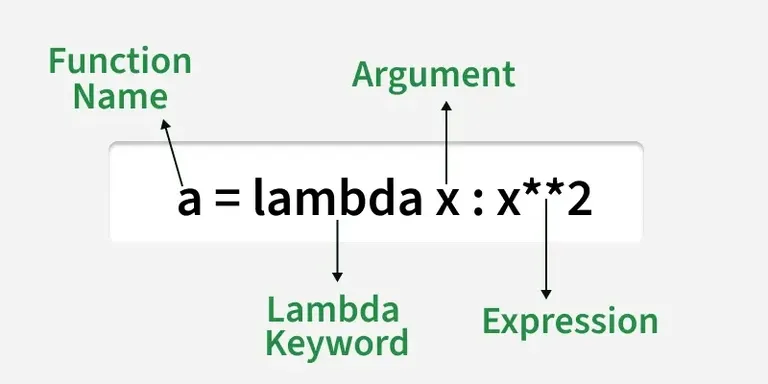

<br>


**Example 1: Simple lambda (one column)**

This example multiplies each total_bill value by 0.18 to compute an estimated tip:

In [ ]:
df['estimated_tip'] = df['total_bill'].apply(lambda bill: bill * 0.18)



*   `df['estimated_tip'] = ...`: This part creates a new column in the DataFrame named estimated_tip
*   `df['total_bill']`: This selects the total_bill column from your DataFrame.
*    `.apply(...)`: This is a pandas Series method that takes a function as an argument and applies that function to each element in the Series.
*    `lambda bill: bill * 0.18`: This is an anonymous (lambda) function.
      * `bill`: is  an arbitrary name for the parameter that this lambda function accepts. When `apply()` iterates through the `df['total_bill']` Series, it passes each individual total_bill value to this lambda function. For each iteration, that total_bill value is temporarily assigned to the bill variable within the scope of the lambda function.

In [ ]:
df.head()

,total_bill,tip,sex,smoker,day,time,size,price_per_person,Payer Name,CC Number,Payment ID,estimated_tip
0,16.99,1.01,Female,No,Sun,Dinner,2,8.49,Christy Cunningham,3560325168603410,Sun2959,3.0582
1,10.34,1.66,Male,No,Sun,Dinner,3,3.45,Douglas Tucker,4478071379779230,Sun4608,1.8612
2,21.01,3.50,Male,No,Sun,Dinner,3,7.00,Travis Walters,6011812112971322,Sun4458,3.7818
3,23.68,3.31,Male,No,Sun,Dinner,2,11.84,Nathaniel Harris,4676137647685994,Sun5260,4.2624
4,24.59,3.61,Female,No,Sun,Dinner,4,6.15,Tonya Carter,4832732618637221,Sun2251,4.4262


This is equivalent to writing a separate function, but more concise.

**Example 2: More Advanced lambda (multiple columns)**

Now let’s recreate the tip category example using a lambda instead of a named function.

This lambda:

 - Computes the tip percentage

 - Returns a label based on the value

In [ ]:
df['tip_category'] = df.apply(
    lambda row: 'Low Tip' if row['tip'] / row['total_bill'] < 0.10
    else 'Average Tip' if row['tip'] / row['total_bill'] < 0.20
    else 'Generous Tip',
    axis=1
)

This code creates a new column `tip_category` by applying a lambda function to each row of the DataFrame. It calculates the tip percentage (`tip / total_bill`) and assigns a category: 'Low Tip' if less than 10%, 'Average Tip' if less than 20% (but not less than 10%), and 'Generous Tip' otherwise.

In [ ]:
df.head()

,total_bill,tip,sex,smoker,day,time,size,price_per_person,Payer Name,CC Number,Payment ID,estimated_tip,tip_category
0,16.99,1.01,Female,No,Sun,Dinner,2,8.49,Christy Cunningham,3560325168603410,Sun2959,3.0582,Low Tip
1,10.34,1.66,Male,No,Sun,Dinner,3,3.45,Douglas Tucker,4478071379779230,Sun4608,1.8612,Average Tip
2,21.01,3.50,Male,No,Sun,Dinner,3,7.00,Travis Walters,6011812112971322,Sun4458,3.7818,Average Tip
3,23.68,3.31,Male,No,Sun,Dinner,2,11.84,Nathaniel Harris,4676137647685994,Sun5260,4.2624,Average Tip
4,24.59,3.61,Female,No,Sun,Dinner,4,6.15,Tonya Carter,4832732618637221,Sun2251,4.4262,Average Tip


<br><br>

### **Performance Comparison: apply() vs. Vectorized Operations (optional)**

Now let’s revisit our tip quality classification example and compare two different approaches to applying the same logic:

  This function takes a row’s total_bill and tip, computes the tip percentage, and returns a label.

In [ ]:
def quality(total_bill, tip):
    if tip / total_bill > 0.25:
        return "Generous"
    else:
        return "Other"


We’ll use the timeit module to measure how long each approach takes when run multiple times.

In [ ]:
import timeit

setup = '''
import numpy as np
import pandas as pd
df = pd.read_csv("tips.csv")

def quality(total_bill, tip):
    if tip / total_bill > 0.25:
        return "Generous"
    else:
        return "Other"
'''


**Method 1: apply() with lambda (row-wise)**

This approach applies the function row by row, which is flexible but slower for large datasets.

In [ ]:
stmt_one = '''
df["Tip Quality"] = df[["total_bill", "tip"]].apply(
    lambda row: quality(row["total_bill"], row["tip"]),
    axis=1
)
'''

**Method 2: Vectorized function with NumPy**

This approach applies the function to entire columns at once using NumPy’s vectorization.


**What are Vectorized Operations?**

Vectorized operations refer to performing operations on entire arrays or Series at once, rather than element by element. NumPy, the numerical computing library for Python, is optimized for these kinds of operations. When you use NumPy functions or operators directly on pandas Series or NumPy arrays, the computations are performed efficiently in optimized, pre-compiled C code.



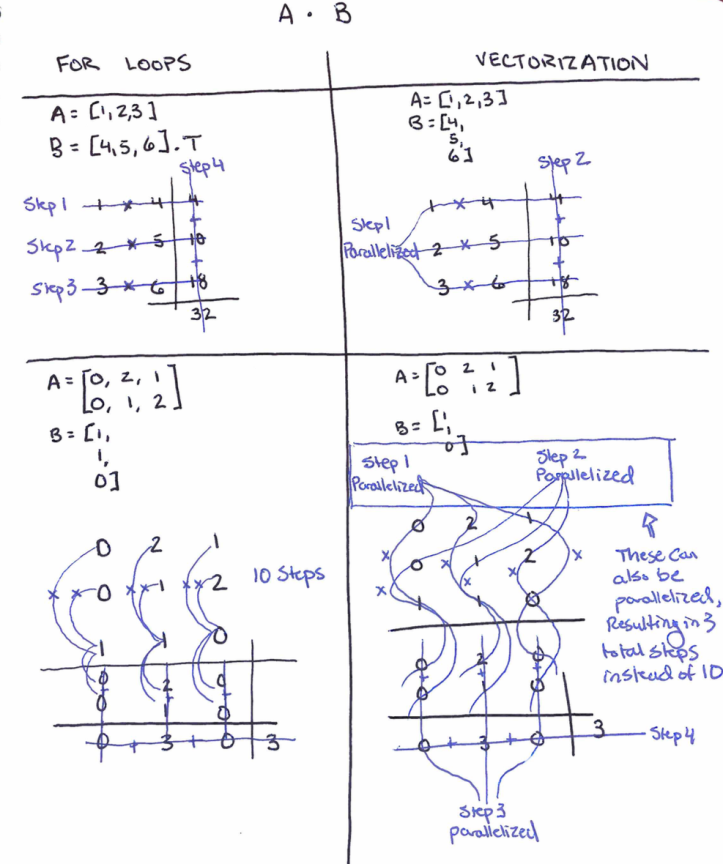

In [ ]:
stmt_two = '''
df["Tip Quality"] = np.vectorize(quality)(df["total_bill"], df["tip"])
'''

**Time both methods**

In [ ]:
timeit.timeit(setup=setup, stmt=stmt_one, number=1000)

3.5533945369998037

In [ ]:
timeit.timeit(setup=setup, stmt=stmt_two, number=1000)

0.6263527070000237

**So, which one is faster?**

In almost all cases, the vectorized version (np.vectorize) will be significantly faster than using apply() with axis=1.

**How does it differ from `apply()`?**

1.  **Execution Style:**
    *   **`apply()` (with custom function or lambda):** This method typically iterates over the DataFrame row by row or element by element in Python. While convenient for complex logic, this Python-level looping can be slow for large datasets because Python's interpreter overhead is incurred for each element.
    *   **Vectorized with NumPy:** Instead of looping in Python, NumPy operations are applied to the entire array or Series simultaneously. For example, when you write `df['total_bill'] * 0.18`, NumPy processes all elements of the `total_bill` Series in one go, without explicit Python loops. Similarly, `np.vectorize()` attempts to turn a regular Python function into a function that can operate on arrays element-wise, though it's often still slower than truly native vectorized NumPy functions.

2.  **Performance:**
    *   **Vectorized operations are generally much faster** than `apply()` for most common data manipulations. This is because the underlying operations are implemented in highly optimized C or Fortran code, avoiding the overhead of Python loops.
    *   As demonstrated in the **Performance Comparison** section you have below, the vectorized NumPy approach is significantly quicker for tasks like applying a simple `quality` function.

3.  **Use Cases:**
    *   **Vectorized:** Ideal for mathematical operations, comparisons, and simple transformations that can be applied uniformly across an entire Series or DataFrame column(s).
    *   **`apply()`:** More flexible for complex logic, conditional statements, or when a function requires access to multiple columns *per row* (using `axis=1`) where direct vectorized NumPy solutions are not immediately obvious or simple.

In essence, always prefer vectorized NumPy operations when possible for performance. Reserve `apply()` for situations where the logic is too complex for straightforward vectorization, or when code readability and ease of expression outweigh the need for maximum speed.

<br><br>

## **Sorting Data with sort_values()**

The sort_values() method allows you to sort a DataFrame by one or more columns.

**Sort by a Single Column**

Sort the data by total_bill in ascending order:

In [ ]:
df_sorted = df.sort_values(by='total_bill')
df_sorted[['total_bill', 'tip']].head()

,total_bill,tip
67,3.07,1.00
92,5.75,1.00
111,7.25,1.00
172,7.25,5.15
149,7.51,2.00


By default:

- Sorting is ascending

- Missing values (if any) are placed at the end

**Sort in Descending Order**

Sort by tip from largest to smallest:

In [ ]:
df_sorted = df.sort_values(by='tip', ascending=False)
df_sorted[['total_bill', 'tip']].head()


,total_bill,tip
170,50.81,10.00
212,48.33,9.00
23,39.42,7.58
59,48.27,6.73
141,34.30,6.70


**Sort by Multiple Columns**

Sort first by day, and within each day sort by total_bill (largest first):

In [43]:
# to be able to sort days correctly by the week rather than alphabetically:
df['day'] =pd.Categorical(df['day'], categories=[ 'Mon', 'Tue', 'Wed', 'Thur', 'Fri', ' Sat','Sun'], ordered=True)

Order Preservation: When you sort a DataFrame containing string columns, pandas sorts them alphabetically. By making the 'day' column ordered=True with specified categories, you ensure that sorting operations (sort_values()) respect the natural calendar order of the days (Mon, Tue, Wed...) rather than alphabetical order (Fri, Mon, Sat...).

In [ ]:
df_sorted = df.sort_values(
    by=['day', 'total_bill'],
    ascending=[True, False]
)

df_sorted[['day', 'total_bill', 'tip']].head()


,day,total_bill,tip
197,Thur,43.11,5.00
142,Thur,41.19,5.00
85,Thur,34.83,5.17
141,Thur,34.30,6.70
83,Thur,32.68,5.00


<br><br>

##**Checking Correlations with df.corr()**

The corr() method calculates the pairwise correlation of numeric columns in a DataFrame. Correlation values range from -1 to 1:

- 1 → perfect positive correlation

- 0 → no correlation

- -1 → perfect negative correlation

**Correlation of all numeric columns**

If dataframe contains only numeric columns:

In [ ]:
df.corr()

ValueError: could not convert string to float: 'Female'

That error happens because df.corr() only works on numeric columns. Your DataFrame contains non-numeric columns like 'sex', 'smoker', 'day', 'time', 'Payer Name', and 'Payment ID', which cannot be converted to floats, so pandas throws a ValueError.

Here’s how to handle it correctly:

**Option 1: Use only numeric columns**

In [ ]:
df.select_dtypes(include='number').corr()

,total_bill,tip,size,price_per_person,CC Number,estimated_tip
total_bill,1.000000,0.675734,0.598315,0.647554,0.104576,1.000000
tip,0.675734,1.000000,0.489299,0.347405,0.110857,0.675734
size,0.598315,0.489299,1.000000,-0.175359,-0.030239,0.598315
price_per_person,0.647554,0.347405,-0.175359,1.000000,0.135240,0.647554
CC Number,0.104576,0.110857,-0.030239,0.135240,1.000000,0.104576
estimated_tip,1.000000,0.675734,0.598315,0.647554,0.104576,1.000000


- select_dtypes(include='number') automatically picks only numeric columns

- Now corr() will work without errors

**Option 2: Select specific numeric columns manually**

In [ ]:
df[['total_bill', 'tip', 'size', 'price_per_person']].corr()

,total_bill,tip,size,price_per_person
total_bill,1.000000,0.675734,0.598315,0.647554
tip,0.675734,1.000000,0.489299,0.347405
size,0.598315,0.489299,1.000000,-0.175359
price_per_person,0.647554,0.347405,-0.175359,1.000000


- Only includes the columns you care about

- Gives a smaller, cleaner correlation matrix

In [ ]:
df[['total_bill', 'tip']].corr()


,total_bill,tip
total_bill,1.000000,0.675734
tip,0.675734,1.000000


**Key Note**

df.corr() cannot automatically ignore non-numeric data. If you have mixed types, always either:

- Filter numeric columns using select_dtypes(include='number')

- Pick the numeric columns manually

<br><br>

##**Finding Minimum and Maximum Values with idxmin() and idxmax()**

The idxmin() and idxmax() methods in pandas are used to find the index (row label) of the minimum or maximum value in a column.

This is useful when you want to know which row has the smallest or largest value, not just the value itself.

**Find the largest and smallest total_bill**

In [ ]:
# Index of the smallest total bill
df['total_bill'].idxmin()

67

In [ ]:
# Index of the largest total bill
df['total_bill'].idxmax()

170

- idxmin() → returns the row index where the value is smallest

- idxmax() → returns the row index where the value is largest

**Get the full row with the largest bill**

This tells you all details of the row with the highest total bill.

In [ ]:
df.loc[df['total_bill'].idxmax()]


,170
total_bill,50.81
tip,10.0
sex,Male
smoker,Yes
day,Sat
time,Dinner
size,3
price_per_person,16.94
Payer Name,Gregory Clark
CC Number,5473850968388236


identifies the row with the smallest tip

In [ ]:
df.loc[df['tip'].idxmin()]

,67
total_bill,3.07
tip,1.0
sex,Female
smoker,Yes
day,Sat
time,Dinner
size,1
price_per_person,3.07
Payer Name,Tiffany Brock
CC Number,4359488526995267


- Only works on numeric columns

- Returns the index (row number), not the value

- Can be combined with .loc[] to fetch the full row

- Great for quick data inspection or reporting extreme values

<br><br>

##**Counting Categories with value_counts()**

The value_counts() method is a quick way to see how many times each category appears in a column.

It works best on categorical columns (strings, object types, or categories).

In [ ]:
df['day'].value_counts()

,count
day,
Sat,87
Sun,76
Thur,62
Fri,19


- Shows which days appear most frequently

- Default sorting is descending by count

In [ ]:
df['sex'].value_counts()

,count
sex,
Male,157
Female,87


**Include missing values**

If a column has NaN values and you want to count them too:

In [ ]:
df['smoker'].value_counts(dropna=False)

,count
smoker,
No,151
Yes,93


dropna=False ensures NaN is included in the counts

<br><br>

## **Replacing Values with replace()**

The replace() method allows you to quickly swap specific values in a DataFrame or Series with something else.

It works on categorical or numeric columns.

**Replace a category**

In [ ]:
df['smoker'].replace({'No': 'Non-Smoker', 'Yes': 'Smoker'}, inplace=True)

/tmp/ipython-input-209271192.py:1: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  df['smoker'].replace({'No': 'Non-Smoker', 'Yes': 'Smoker'}, inplace=True)


- Now the smoker column will have only "Smoker" or "Non-Smoker"

- inplace=True updates the DataFrame directly

In [ ]:
df['smoker'].value_counts()

,count
smoker,
Non-Smoker,151
Smoker,93


**Replace numeric values**

You can also replace numeric values. For example, if you want to replace a tip of 0 with NaN:

In [ ]:
df['tip'].replace(0, np.nan, inplace=True)

/tmp/ipython-input-2774048939.py:1: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  df['tip'].replace(0, np.nan, inplace=True)


**Replace multiple values at once**

Cleans up inconsistent labeling in your data

In [ ]:
df['day'].replace({'Thur': 'Thursday', 'Sat': 'Saturday', 'Sun': 'Sunday', 'Fri': 'Friday'}, inplace=True)

/tmp/ipython-input-4120478182.py:1: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  df['day'].replace({'Thur': 'Thursday', 'Sat': 'Saturday', 'Sun': 'Sunday', 'Fri': 'Friday'}, inplace=True)


<br><br>

## **Finding Unique Values with unique() and nunique()**

Pandas provides two handy methods to explore unique entries in a column:

- unique() → Returns an array of all unique values

- nunique() → Returns the count of unique values

usage:

- Works on both numeric and categorical columns

- Useful for data exploration, cleaning, and feature engineering

- These methods are very useful for categorical columns or for checking diversity of data.

In [ ]:
df['day'].unique()

array(['Sunday', 'Saturday', 'Thursday', 'Friday'], dtype=object)

- Shows all distinct values in the day column

- Useful to check for typos or inconsistencies

In [ ]:
df['day'].nunique()

4

Tells us there are 4 unique days in the dataset

**Apply on numeric column**

In [ ]:
df['size'].unique()

array([2, 3, 4, 1, 6, 5])

Returns all distinct party sizes in the dataset

In [ ]:
df['size'].nunique()

6

Returns how many different party sizes exist

<br><br>

## **Transforming Column Values with map()**

The map() method in pandas is used to apply a function or a mapping dictionary to each value in a Series.

It works on one column at a time and is especially useful for simple transformations or recoding values.

**Map a dictionary to a column**

Suppose we want to recode the sex column:

In [ ]:
df['sex_mapped'] = df['sex'].map({'Male': 1, 'Female': 0})

- "Male" becomes 1, "Female" becomes 0

- Creates a new numeric column for easier analysis

In [ ]:
df[['sex', 'sex_mapped']].head()

,sex,sex_mapped
0,Female,0
1,Male,1
2,Male,1
3,Male,1
4,Female,0


**Map a function to a column**

You can also apply a custom function to transform values:

In [ ]:
df['size_label'] = df['size'].map(lambda x: 'Small' if x <= 2 else 'Large')

- Party sizes 1 or 2 → "Small"

- Party sizes >2 → "Large"

In [ ]:
df[['size', 'size_label']].head()

,size,size_label
0,2,Small
1,3,Large
2,3,Large
3,2,Small
4,4,Large


**Map numeric transformation**

In [ ]:
df['tip_rounded'] = df['tip'].map(lambda t: round(t))

**Key Notes**

- map() works on Series (one column), not full DataFrames
- Can accept:
  - A dictionary → for mapping values
  - A function / lambda → for transformations
- Good for feature engineering, label encoding, or quick transformations

<br><br>

## **Detecting and Removing Duplicates**

Pandas provides two useful methods for working with duplicate rows:

- .duplicated() → Identifies duplicate rows

- .drop_duplicates() → Removes duplicate rows

These are especially helpful when cleaning datasets.

**Identify duplicate rows**

In [ ]:
df.duplicated().head()

,0
0,False
1,False
2,False
3,False
4,False


- Returns a Boolean Series: True if the row is a duplicate of a previous row, False otherwise

- By default, considers all columns

In [ ]:
# Count how many duplicate rows exist
df.duplicated().sum()

np.int64(0)

**Drop duplicate rows**

In [ ]:
df_no_duplicates = df.drop_duplicates()

- Returns a new DataFrame without duplicate rows

- Original df remains unchanged unless you use inplace=True

In [ ]:
df.drop_duplicates(inplace=True)

**Check for duplicates based on specific columns**

Suppose we want to remove duplicates based only on total_bill and tip:

In [ ]:
df.drop_duplicates(subset=['total_bill', 'tip'], inplace=True)

- Only considers the specified columns for identifying duplicates

- Keeps the first occurrence by default

<br><br>

## **Filtering Values with between()**

The between() method is a convenient way to check if values fall within a range.
It returns a Boolean Series, which can be used to filter your DataFrame.

Parameters:

- left → The lower boundary (scalar)
- right → The upper boundary (scalar)
- inclusive → Boolean (default True)
  - True → includes the boundaries
  - False → excludes the boundaries

**Filter bills between 10 and 20 (inclusive)**

Returns all rows where total_bill >= 10 and total_bill <= 20

In [ ]:
df[df['total_bill'].between(10, 20)]

,total_bill,tip,sex,smoker,day,time,size,price_per_person,Payer Name,CC Number,Payment ID,estimated_tip,tip_category,sex_mapped,size_label,tip_rounded
0,16.99,1.01,Female,Non-Smoker,Sunday,Dinner,2,8.49,Christy Cunningham,3560325168603410,Sun2959,3.0582,Low Tip,0,Small,1
1,10.34,1.66,Male,Non-Smoker,Sunday,Dinner,3,3.45,Douglas Tucker,4478071379779230,Sun4608,1.8612,Average Tip,1,Large,2
8,15.04,1.96,Male,Non-Smoker,Sunday,Dinner,2,7.52,Joseph Mcdonald,3522866365840377,Sun6820,2.7072,Average Tip,1,Small,2
9,14.78,3.23,Male,Non-Smoker,Sunday,Dinner,2,7.39,Jerome Abbott,3532124519049786,Sun3775,2.6604,Generous Tip,1,Small,3
10,10.27,1.71,Male,Non-Smoker,Sunday,Dinner,2,5.14,William Riley,566287581219,Sun2546,1.8486,Average Tip,1,Small,2
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
234,15.53,3.00,Male,Smoker,Saturday,Dinner,2,7.76,Tracy Douglas,4097938155941930,Sat7220,2.7954,Average Tip,1,Small,3
235,10.07,1.25,Male,Non-Smoker,Saturday,Dinner,2,5.04,Sean Gonzalez,3534021246117605,Sat4615,1.8126,Average Tip,1,Small,1
236,12.60,1.00,Male,Smoker,Saturday,Dinner,2,6.30,Matthew Myers,3543676378973965,Sat5032,2.2680,Low Tip,1,Small,1
242,17.82,1.75,Male,Non-Smoker,Saturday,Dinner,2,8.91,Dennis Dixon,4375220550950,Sat17,3.2076,Low Tip,1,Small,2


**Exclude the boundaries**

- Returns rows where 10 < total_bill < 20
- Useful when you want strictly inside the range

In [ ]:
df[df['total_bill'].between(10, 20, inclusive='neither')]

,total_bill,tip,sex,smoker,day,time,size,price_per_person,Payer Name,CC Number,Payment ID,estimated_tip,tip_category,sex_mapped,size_label,tip_rounded
0,16.99,1.01,Female,Non-Smoker,Sunday,Dinner,2,8.49,Christy Cunningham,3560325168603410,Sun2959,3.0582,Low Tip,0,Small,1
1,10.34,1.66,Male,Non-Smoker,Sunday,Dinner,3,3.45,Douglas Tucker,4478071379779230,Sun4608,1.8612,Average Tip,1,Large,2
8,15.04,1.96,Male,Non-Smoker,Sunday,Dinner,2,7.52,Joseph Mcdonald,3522866365840377,Sun6820,2.7072,Average Tip,1,Small,2
9,14.78,3.23,Male,Non-Smoker,Sunday,Dinner,2,7.39,Jerome Abbott,3532124519049786,Sun3775,2.6604,Generous Tip,1,Small,3
10,10.27,1.71,Male,Non-Smoker,Sunday,Dinner,2,5.14,William Riley,566287581219,Sun2546,1.8486,Average Tip,1,Small,2
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
234,15.53,3.00,Male,Smoker,Saturday,Dinner,2,7.76,Tracy Douglas,4097938155941930,Sat7220,2.7954,Average Tip,1,Small,3
235,10.07,1.25,Male,Non-Smoker,Saturday,Dinner,2,5.04,Sean Gonzalez,3534021246117605,Sat4615,1.8126,Average Tip,1,Small,1
236,12.60,1.00,Male,Smoker,Saturday,Dinner,2,6.30,Matthew Myers,3543676378973965,Sat5032,2.2680,Low Tip,1,Small,1
242,17.82,1.75,Male,Non-Smoker,Saturday,Dinner,2,8.91,Dennis Dixon,4375220550950,Sat17,3.2076,Low Tip,1,Small,2


**Combine with other conditions**

- Filters tips within a range and party size greater than 3
- Demonstrates how between() works well in complex filtering



In [ ]:
# Tips between 2 and 5 for large parties only
df[df['tip'].between(2, 5) & (df['size'] > 3)]

,total_bill,tip,sex,smoker,day,time,size,price_per_person,Payer Name,CC Number,Payment ID,estimated_tip,tip_category,sex_mapped,size_label,tip_rounded
4,24.59,3.61,Female,Non-Smoker,Sunday,Dinner,4,6.15,Tonya Carter,4832732618637221,Sun2251,4.4262,Average Tip,0,Large,4
5,25.29,4.71,Male,Non-Smoker,Sunday,Dinner,4,6.32,Erik Smith,213140353657882,Sun9679,4.5522,Average Tip,1,Large,5
7,26.88,3.12,Male,Non-Smoker,Sunday,Dinner,4,6.72,Robert Buck,3514785077705092,Sun8157,4.8384,Average Tip,1,Large,3
11,35.26,5.00,Female,Non-Smoker,Sunday,Dinner,4,8.82,Diane Macias,4577817359320969,Sun6686,6.3468,Average Tip,0,Large,5
13,18.43,3.00,Male,Non-Smoker,Sunday,Dinner,4,4.61,Joshua Jones,6011163105616890,Sun2971,3.3174,Average Tip,1,Large,3
25,17.81,2.34,Male,Non-Smoker,Saturday,Dinner,4,4.45,Robert Perkins,30502930499388,Sat907,3.2058,Average Tip,1,Large,2
31,18.35,2.50,Male,Non-Smoker,Saturday,Dinner,4,4.59,Danny Santiago,630415546013,Sat4947,3.3030,Average Tip,1,Large,2
33,20.69,2.45,Female,Non-Smoker,Saturday,Dinner,4,5.17,Amber Francis,377742985258914,Sat6649,3.7242,Average Tip,0,Large,2
54,25.56,4.34,Male,Non-Smoker,Sunday,Dinner,4,6.39,Ronald Owens,6569607991983380,Sun9470,4.6008,Average Tip,1,Large,4
56,38.01,3.00,Male,Smoker,Saturday,Dinner,4,9.50,James Christensen DDS,349793629453226,Sat8903,6.8418,Low Tip,1,Large,3


<br><br>

## **Random Sampling with sample()**

The sample() method allows you to take a random sample of rows from a DataFrame.
It’s useful for exploring large datasets, testing, or creating training/test splits.

**Randomly select n rows**

In [ ]:
df.sample(5)


,total_bill,tip,sex,smoker,day,time,size,price_per_person,Payer Name,CC Number,Payment ID,estimated_tip,tip_category,sex_mapped,size_label,tip_rounded
61,13.81,2.00,Male,Smoker,Saturday,Dinner,2,6.90,Ryan Hernandez,4766834726806,Sat3030,2.4858,Average Tip,1,Small,2
103,22.42,3.48,Female,Smoker,Saturday,Dinner,2,11.21,Kathleen Hawkins,348009865484721,Sat1015,4.0356,Average Tip,0,Small,3
240,27.18,2.00,Female,Smoker,Saturday,Dinner,2,13.59,Monica Sanders,3506806155565404,Sat1766,4.8924,Low Tip,0,Small,2
112,38.07,4.00,Male,Non-Smoker,Sunday,Dinner,3,12.69,Jeff Lopez,3572865915176463,Sun591,6.8526,Average Tip,1,Large,4
72,26.86,3.14,Female,Smoker,Saturday,Dinner,2,13.43,Victoria Obrien MD,4216245673726,Sat1967,4.8348,Average Tip,0,Small,3


- Returns 5 random rows from the DataFrame
- Each call returns different rows by default

**Fractional sampling**

In [ ]:
# Sample 10% of the dataset
df.sample(frac=0.1, random_state=42)

,total_bill,tip,sex,smoker,day,time,size,price_per_person,Payer Name,CC Number,Payment ID,estimated_tip,tip_category,sex_mapped,size_label,tip_rounded
24,19.82,3.18,Male,Non-Smoker,Saturday,Dinner,2,9.91,Christopher Ross,36739148167928,Sat6236,3.5676,Average Tip,1,Small,3
6,8.77,2.00,Male,Non-Smoker,Sunday,Dinner,2,4.38,Kristopher Johnson,2223727524230344,Sun5985,1.5786,Generous Tip,1,Small,2
152,17.26,2.74,Male,Non-Smoker,Sunday,Dinner,3,5.75,Gregory Smith,4292362333741,Sun5205,3.1068,Average Tip,1,Large,3
211,25.89,5.16,Male,Smoker,Saturday,Dinner,4,6.47,Christopher Li,6011962464150569,Sat6735,4.6602,Average Tip,1,Large,5
239,29.03,5.92,Male,Non-Smoker,Saturday,Dinner,3,9.68,Michael Avila,5296068606052842,Sat2657,5.2254,Generous Tip,1,Large,6
200,18.71,4.00,Male,Smoker,Thursday,Lunch,3,6.24,Jason Conrad,4581233003487,Thur6048,3.3678,Generous Tip,1,Large,4
191,19.81,4.19,Female,Smoker,Thursday,Lunch,2,9.90,Kristy Boyd,4317015327600068,Thur967,3.5658,Generous Tip,0,Small,4
150,14.07,2.50,Male,Non-Smoker,Sunday,Dinner,2,7.04,Luke Rice,4813617017359506,Sun8863,2.5326,Average Tip,1,Small,2
9,14.78,3.23,Male,Non-Smoker,Sunday,Dinner,2,7.39,Jerome Abbott,3532124519049786,Sun3775,2.6604,Generous Tip,1,Small,3
113,23.95,2.55,Male,Non-Smoker,Sunday,Dinner,2,11.98,John Joyce,6565964211060570,Sun1885,4.3110,Average Tip,1,Small,3


- Returns 10% of rows randomly
- frac is a float between 0 and 1

**Sampling with replacement**

In [ ]:
df.sample(n=5, replace=True)

,total_bill,tip,sex,smoker,day,time,size,price_per_person,Payer Name,CC Number,Payment ID,estimated_tip,tip_category,sex_mapped,size_label,tip_rounded
62,11.02,1.98,Male,Smoker,Saturday,Dinner,2,5.51,Joseph Hart,180046232326178,Sat2265,1.9836,Average Tip,1,Small,2
19,20.65,3.35,Male,Non-Smoker,Saturday,Dinner,3,6.88,Timothy Oneal,6568069240986485,Sat9213,3.7170,Average Tip,1,Large,3
241,22.67,2.00,Male,Smoker,Saturday,Dinner,2,11.34,Keith Wong,6011891618747196,Sat3880,4.0806,Low Tip,1,Small,2
85,34.83,5.17,Female,Non-Smoker,Thursday,Lunch,4,8.71,Shawna Cook,6011787464177340,Thur7972,6.2694,Average Tip,0,Large,5
87,18.28,4.00,Male,Non-Smoker,Thursday,Lunch,2,9.14,Donald Williams,5363745772301404,Thur3636,3.2904,Generous Tip,1,Small,4


- Allows the same row to appear multiple times in the sample
- Useful for bootstrapping or resampling techniques

<br><br>

## **Selecting Top or Bottom Values with nlargest() and nsmallest()**

Pandas provides quick methods to get the largest or smallest values in a column along with their rows:

- nlargest(n, columns) → Returns the top n rows sorted by the column
- nsmallest(n, columns) → Returns the bottom n rows sorted by the column

These are faster and more convenient than sorting and then taking slices.

In [ ]:
df.nlargest(5, 'total_bill')

,total_bill,tip,sex,smoker,day,time,size,price_per_person,Payer Name,CC Number,Payment ID,estimated_tip,tip_category,sex_mapped,size_label,tip_rounded
170,50.81,10.00,Male,Smoker,Saturday,Dinner,3,16.94,Gregory Clark,5473850968388236,Sat1954,9.1458,Average Tip,1,Large,10
212,48.33,9.00,Male,Non-Smoker,Saturday,Dinner,4,12.08,Alex Williamson,676218815212,Sat4590,8.6994,Average Tip,1,Large,9
59,48.27,6.73,Male,Non-Smoker,Saturday,Dinner,4,12.07,Brian Ortiz,6596453823950595,Sat8139,8.6886,Average Tip,1,Large,7
156,48.17,5.00,Male,Non-Smoker,Sunday,Dinner,6,8.03,Ryan Gonzales,3523151482063321,Sun7518,8.6706,Average Tip,1,Large,5
182,45.35,3.50,Male,Smoker,Sunday,Dinner,3,15.12,Jose Parsons,4112207559459910,Sun2337,8.1630,Low Tip,1,Large,4


In [ ]:
df.nsmallest(3, 'tip')


,total_bill,tip,sex,smoker,day,time,size,price_per_person,Payer Name,CC Number,Payment ID,estimated_tip,tip_category,sex_mapped,size_label,tip_rounded
67,3.07,1.0,Female,Smoker,Saturday,Dinner,1,3.07,Tiffany Brock,4359488526995267,Sat3455,0.5526,Generous Tip,0,Small,1
92,5.75,1.0,Female,Smoker,Friday,Dinner,2,2.88,Leah Ramirez,3508911676966392,Fri3780,1.0350,Average Tip,0,Small,1
111,7.25,1.0,Female,Non-Smoker,Saturday,Dinner,1,7.25,Terri Jones,3559221007826887,Sat4801,1.3050,Average Tip,0,Small,1


In [ ]:
# Top 5 largest bills, if tie, sort by tip descending
df.nlargest(5, ['total_bill', 'tip'])


,total_bill,tip,sex,smoker,day,time,size,price_per_person,Payer Name,CC Number,Payment ID,estimated_tip,tip_category,sex_mapped,size_label,tip_rounded
170,50.81,10.00,Male,Smoker,Saturday,Dinner,3,16.94,Gregory Clark,5473850968388236,Sat1954,9.1458,Average Tip,1,Large,10
212,48.33,9.00,Male,Non-Smoker,Saturday,Dinner,4,12.08,Alex Williamson,676218815212,Sat4590,8.6994,Average Tip,1,Large,9
59,48.27,6.73,Male,Non-Smoker,Saturday,Dinner,4,12.07,Brian Ortiz,6596453823950595,Sat8139,8.6886,Average Tip,1,Large,7
156,48.17,5.00,Male,Non-Smoker,Sunday,Dinner,6,8.03,Ryan Gonzales,3523151482063321,Sun7518,8.6706,Average Tip,1,Large,5
182,45.35,3.50,Male,Smoker,Sunday,Dinner,3,15.12,Jose Parsons,4112207559459910,Sun2337,8.1630,Low Tip,1,Large,4


<br><br><br><br><br><br><br><br>

**Reference:** Pierian Data — Python & Data Science Training  
https://pieriantraining.com